# Tutorial 2: Compute topological features

This note book illustrates how one can compute topological features (persistence diagrams, Dowker persistence diagrams).

In [1]:
using Pkg
Pkg.activate("../.")
Pkg.instantiate()

  Activating project at `~/Documents/lung_ECM_TDA_new`


In [ ]:
include("../src/dowker_persistence.jl")
include("../src/Eirene_var.jl")
include("../src/TDA.jl")

using .Dowker
using .Eirene_var
using .TDA
using DelimitedFiles
using DataFrames
using Plots
using CSV
using PersistenceDiagrams
gr()

WebIO._IJuliaInit()

Plots.GRBackend()

In [3]:
# plotting parameters
c_highlight = :deeppink2

### for point cloud
p_markersize = 5
p_markerstrokewidth = 0.1
p_imagesize = (300, 300)

### for PD
diagonal_lw = 2
pd_markersize = 15
tickfontsize = 25
PD_size = (500, 500)
inf_markerstrokewidth = 6

6

In [7]:
# load points
points = CSV.read("../data/pointcloud/ECM/ROI5.csv", DataFrame);

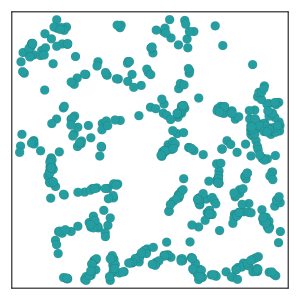

In [8]:
# # plot points
p = scatter(points[:,1], points[:,2],
            markersize = p_markersize,
                 yflip = true,
                 label = "",
                 markerstrokewidth = p_markerstrokewidth,
                 frame = :box,
                 ticks = [],
                 aspect = :equal, size = p_imagesize, 
                 c = "#249EA0", # purple
                 )

plot(p)

In [9]:
PD0, PD1 = run_PH(points)

([0.0 2.0; 0.0 2.23606797749979; … ; 0.0 531.8966064941569; 0.0 Inf], [59.481089431852205 60.21627686929839; 183.5755975068582 184.39088914585776; … ; 542.3218601531751 926.0955674227148; 308.084404019418 920.3912211663038])

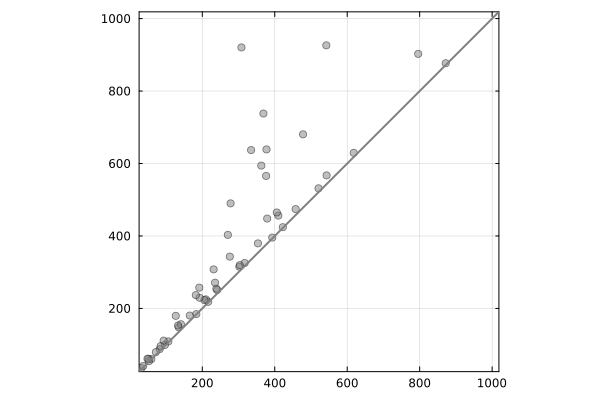

In [10]:
TDA.plot_PD(PD1, diagonal_lw= 2)

# Dimension-0 Dowker persistence diagram (DPD0)

Note: It's always a good idea to plot the two cell types and ensure that they are somewhat aligned. 

In [27]:
celltype1 = Array(CSV.read("../data/downsampled_pointcloud/cancer/ROI1.csv", DataFrame))
celltype2 = Array(CSV.read("../data/downsampled_pointcloud/leukocytes/ROI1.csv", DataFrame));

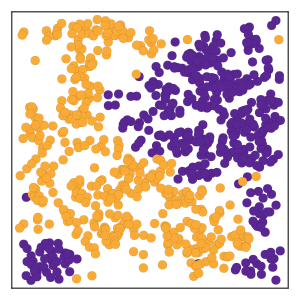

In [28]:
# plot the two cell types
p = scatter(celltype1[:,1], celltype1[:,2],
            markersize = p_markersize,
                 yflip = true,
                 label = "",
                 markerstrokewidth = p_markerstrokewidth,
                 frame = :box,
                 ticks = [],
                 c =  "#592693" # purple
                 )
scatter!(p, celltype2[:,1], celltype2[:,2],
            markersize = p_markersize,
                 yflip = true,
                 label = "",
                markerstrokewidth = p_markerstrokewidth,
                 frame = :box,
                 ticks = [],
                 c = "#FAAB36" # orange
                 )
plot(p, aspect = :equal, size = p_imagesize,  
        background_color=:transparent, foreground_color=:black
        )
#savefig("figures/two_celltypes.pdf")

The following cell computes the Dowker persistence diagram. Note that Dowker persistence diagram computation takes longer than the regular persistence diagram computation. For example, the following cell will take ~5 min on a standard laptop.

In [29]:
# compute Dowker persistence diagram
DPD0, DPD1, _ = compute_Dowker(celltype1, celltype2);

LoadError: InterruptException:

Plot dimension-0 Dowker persistence diagram

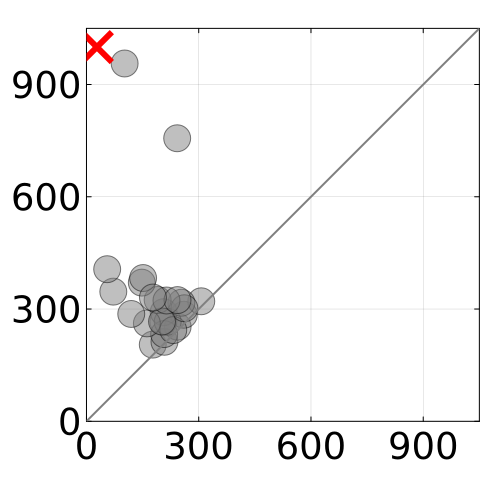

In [67]:
p = TDA.plot_PD(DPD0;
        pd_min = 0,
        pd_max = 1050,
        inf_coord = 1000,
        ticks = [0, 300, 600, 900],
        diagonal_lw = diagonal_lw,
        markersize = pd_markersize,
        #highlight = [3, 24],
        tickfontsize = tickfontsize,
        inf_markerstrokewidth = inf_markerstrokewidth,
        size = PD_size,
        right_margin = 3Plots.mm,
        background_color=:transparent, foreground_color=:black)

A persistence image vectorizes the persistence diagram. It provides a visual summary of the points on the persistence diagram.


In [72]:
 # convert to Ripser PD
 PH0 = array_to_ripsererPD(DPD0)

 # compute PI
 PI0 = PersistenceImage(PH0)

LoadError: MethodError: no method matching persistence(::Float64)

[0mClosest candidates are:
[0m  persistence([91m::PersistenceInterval[39m)
[0m[90m   @[39m [36mPersistenceDiagrams[39m [90m~/.julia/packages/PersistenceDiagrams/KQGLj/src/[39m[90m[4mintervals.jl:64[24m[39m


# Dimension-1 Dowker persistence diagram (DPD1)

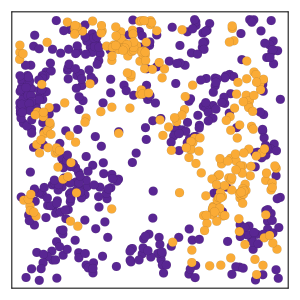

In [7]:
# load points
celltype1 = readdlm("DowkerPH_inputs/cell_type1/ROI1.csv", ',')
celltype2 = readdlm("DowkerPH_inputs/cell_type2/ROI1.csv", ',');

# plot the two cell types
p = scatter(celltype1[:,1], celltype1[:,2],
            markersize = p_markersize,
                 yflip = true,
                 label = "",
                 markerstrokewidth = p_markerstrokewidth,
                 frame = :box,
                 ticks = [],
                 c =  "#592693" # purple
                 )
scatter!(p, celltype2[:,1], celltype2[:,2],
            markersize = p_markersize,
                 yflip = true,
                 label = "",
                markerstrokewidth = p_markerstrokewidth,
                 frame = :box,
                 ticks = [],
                 c = "#FAAB36" # orange
                 )
plot(p, aspect = :equal, size = p_imagesize,  
        background_color=:transparent, foreground_color=:black
        )

In [ ]:
# compute Dowker persistence diagram
DPD0, DPD1, _ = compute_Dowker(celltype1, celltype2);

In [ ]:
# plot all subsampled cells 


cell_dir = "../data/downsampled_pointcloud/cancer/"
csv_files = [item for item in walkdir(cell_dir)][1][3:end][1]


for (idx, file) in enumerate(csv_files)

    # load sampled cells
    celltype1 = CSV.read("../data/downsampled_pointcloud/cancer/" * file, DataFrame)
    celltype2 = CSV.read("../data/downsampled_pointcloud/leukocytes/" * file, DataFrame);
    print(file)

    # plot the two cell types
    p = scatter(celltype1[:,1], celltype1[:,2],
                 markersize = p_markersize,
                     yflip = true,
                     label = "",
                     markerstrokewidth = p_markerstrokewidth,
                     frame = :box,
                     ticks = [],
                     c =  "#592693" # purple
                     )
    scatter!(p, celltype2[:,1], celltype2[:,2],
                markersize = p_markersize,
                    yflip = true,
                    label = "",
                    markerstrokewidth = p_markerstrokewidth,
                    frame = :box,
                    ticks = [],
                    c = "#FAAB36" # orange
                    )
    plot(p, aspect = :equal, size = p_imagesize,  
            background_color=:transparent, foreground_color=:black
            )
    filename = split(file,".")[1]
    savefig("../data/downsampled_pointcloud/cancer_leukocytes_plots/" * filename * ".pdf")

end 

ROI1.csvROI2.csvROI3.csvROI4.csvROI5.csvROI6.csvROI7.csvROI8.csv